In [1]:
import os
import torch
import torch.nn as nn
from transformers import AutoConfig, AutoModelForSequenceClassification
from safetensors.torch import load_file  # comes with HF if safetensors installed
import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")

: 

In [ ]:
def load_custom_bert_from_checkpoint(ckpt_path: str):
    # 1. Load the saved config (includes custom_hidden, custom_num_layers)
    config = AutoConfig.from_pretrained(ckpt_path)

    # 2. Build a model from config (bare BertForSequenceClassification)
    model = AutoModelForSequenceClassification.from_config(config)

    # 3. Rebuild the SAME classifier architecture as in training
    hidden = getattr(config, "custom_hidden", 512)  # fallback if not in config
    num_layers = getattr(config, "custom_num_layers", 1)

    layers = []
    for i in range(num_layers):
        in_dim = config.hidden_size if i == 0 else hidden
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(nn.GELU())
        layers.append(nn.Dropout(0.2))

    layers.append(nn.Linear(hidden, config.num_labels))
    model.classifier = nn.Sequential(*layers)

    # 4. Load weights from model.safetensors
    state_dict = load_file(os.path.join(ckpt_path, "model.safetensors"))
    model.load_state_dict(state_dict, strict=True)  # will fail loudly if mismatch

    # 5. Inference mode
    model.eval()
    return model

In [3]:
def BERT_classification_chunk(chunk: str, model, tokenizer):

    inputs = tokenizer(chunk, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(0)
        label_scores = {
            model.config.id2label[i]: logits[i].item()
            for i in range(logits.size(0))
        }

    return label_scores

In [4]:
ckpt_path = "results/BERT_models/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331"
ckpt = "results/BERT_models/results__new_approach_data__num_layers_2bert-base-uncased__train_full_model__some_labels/checkpoint-15990"
model = load_custom_bert_from_checkpoint(ckpt_path)

tokenizer = AutoTokenizer.from_pretrained(ckpt_path) 

In [5]:
BERT_classification_chunk("HI", model, tokenizer)

{'F': 1.3136913776397705,
 'P': -0.8579303026199341,
 'L': -3.8988454341888428,
 'K': 0.12282141298055649,
 'I': 0.04591423273086548,
 'A': -3.320859670639038,
 'D': -2.7458183765411377,
 'G': -1.2696043252944946,
 'E': -1.9209752082824707,
 'NO_CLASS': 8.289066314697266,
 'B': -3.1888816356658936,
 'J': -3.048295021057129,
 'H': 0.25600868463516235,
 'Q': 0.8949542045593262,
 'M': -0.00171646848320961,
 'N': 0.16992051899433136,
 'C': -0.48474830389022827}

In [6]:
def get_max_class(chunk, model, tokenizer): 
    res = BERT_classification_chunk(chunk, model, tokenizer)
    return max(res, key=res.get)

## Test: load all the similarities chunks inclusive the similarities to all the similar classes of one 

In [7]:
dataset_path = "data/datasets/stoxx_600"
dataset_path = "data/datasets/reports_subset_from_full_data_1"
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=",")

In [8]:
report_path = "results/benchmark_sentence_similarities_only/paragraph_and_sentence_len_6_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_extended"
report_path = "results/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1"
report_paths = glob.glob(report_path + "/*/*long.csv")
len(report_paths)

1556

In [9]:
report = report_paths[3]

In [10]:
df_report = pd.read_csv(report, index_col=0)
scores = [c for c in df_report.columns if "Scores" in c]
df_report["max_class_sim"] = [scores[i][7] for i in np.argmax(df_report[scores], 1)]
df_report["max_sim"] = df_report[scores].max(1)

In [11]:
report_name = os.path.basename(report).split(".txt")[0] + ".pdf"
report_name

'Genex Power Ltd.1.pdf'

In [12]:
report_code = nace_classes[nace_classes["Report"] == report_name]["NACE_letter"].item()
report_code

'D'

In [13]:
df_report["right_class_sim"] = df_report["max_class_sim"] == report_code

In [14]:
df_report["BERT_classification"] = df_report.loc[:,"Sentences"].apply(lambda x: get_max_class(x, model, tokenizer))

In [15]:
np.mean(df_report[df_report["right_class_sim"]]["BERT_classification"] == df_report[df_report["right_class_sim"]]["max_class_sim"])

np.float64(0.18333333333333332)

In [16]:
df_report[(df_report["right_class_sim"]) & (df_report["max_sim"]>0.3)]

,Sentences,"Scores_A_AGRICULTURE, FORESTRY AND FISHING",Scores_B_MINING AND QUARRYING,Scores_C_MANUFACTURING,"Scores_D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY","Scores_E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES",Scores_F_CONSTRUCTION,Scores_G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES,Scores_H_TRANSPORTATION AND STORAGE,Scores_I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES,...,Scores_P_EDUCATION,Scores_Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES,"Scores_R_ARTS, ENTERTAINMENT AND RECREATION",Scores_S_OTHER SERVICE ACTIVITIES,Scores_T_ACTIVITIES OF HOUSEHOLDS AS EMPLOYERS; UNDIFFERENTIATED GOODS- AND SERVICES-PRODUCING ACTIVITIES OF HOUSEHOLDS FOR OWN USE,Scores_U_ACTIVITIES OF EXTRATERRITORIAL ORGANISATIONS AND BODIES,max_class_sim,max_sim,right_class_sim,BERT_classification
9,we are a proud developer of sustainable renewa...,0.169232,0.234612,0.179749,0.338000,0.264856,0.210002,0.109806,0.157785,0.157287,...,0.033011,0.090272,0.086375,0.167314,0.154467,0.126453,D,0.338000,True,D
22,management has determined that the consolidate...,0.249061,0.329127,0.340917,0.412389,0.315880,0.388133,0.353952,0.311651,0.275470,...,0.202877,0.217354,0.161955,0.299488,0.246260,0.237611,D,0.412389,True,D
99,revenue and other income of .m an increase of ...,0.224630,0.256487,0.211886,0.394047,0.289178,0.330740,0.297819,0.334659,0.288004,...,0.183794,0.168645,0.203596,0.265761,0.236658,0.181109,D,0.394047,True,D
120,a sustainability and climate change policy whi...,0.210658,0.236546,0.195265,0.305788,0.275317,0.162119,0.227680,0.203108,0.193936,...,0.107694,0.139062,0.108816,0.186910,0.297123,0.252052,D,0.305788,True,NO_CLASS
122,i would like to acknowledge the ongoing strong...,0.154058,0.194401,0.182168,0.321150,0.161849,0.212890,0.123775,0.164404,0.140653,...,0.082526,0.038751,0.078045,0.104284,0.020213,0.105024,D,0.321150,True,D
128,i would again like to acknowledge the support ...,0.188339,0.237051,0.190781,0.334850,0.192824,0.246860,0.139009,0.210160,0.195523,...,0.157388,0.085401,0.091679,0.148094,0.073686,0.126307,D,0.334850,True,D
132,despite reduced irradiance owing to la nina we...,0.186999,0.142981,0.133600,0.302657,0.148379,0.199401,0.121929,0.128209,0.131019,...,0.073498,0.062907,0.060474,0.088933,0.077359,0.109444,D,0.302657,True,NO_CLASS
154,the consolidated entitys principal activities ...,0.311888,0.300335,0.269778,0.397606,0.366883,0.340815,0.248745,0.261832,0.241068,...,0.191034,0.255020,0.204082,0.301102,0.239940,0.246493,D,0.397606,True,F
166,genex power limited is an australian publicly ...,0.105063,0.111500,0.130054,0.322589,0.122441,0.169637,0.080063,0.103943,0.078068,...,-0.009102,0.019697,0.044829,0.079871,-0.005823,0.033495,D,0.322589,True,NO_CLASS
207,similarly jsp also continued to perform well t...,0.249343,0.208611,0.206112,0.386500,0.208569,0.223802,0.249790,0.209426,0.194014,...,0.119055,0.065275,0.096051,0.160776,0.141195,0.135793,D,0.386500,True,D


In [17]:
np.mean(df_report[(df_report["right_class_sim"]) & (df_report["max_sim"]>0.3)]["BERT_classification"] == df_report[(df_report["right_class_sim"]) & (df_report["max_sim"]>0.3)]["max_class_sim"])

np.float64(0.3142857142857143)

In [18]:
df_report[df_report["right_class_sim"]]["max_class_sim"]

7      D
9      D
22     D
34     D
42     D
60     D
72     D
99     D
115    D
120    D
122    D
128    D
132    D
149    D
154    D
166    D
170    D
206    D
207    D
214    D
224    D
230    D
235    D
245    D
255    D
258    D
263    D
266    D
280    D
286    D
287    D
290    D
305    D
316    D
339    D
343    D
354    D
374    D
378    D
394    D
406    D
410    D
412    D
421    D
426    D
436    D
442    D
443    D
446    D
447    D
501    D
503    D
518    D
519    D
532    D
537    D
541    D
545    D
550    D
559    D
Name: max_class_sim, dtype: object

In [19]:
df_report[df_report["right_class_sim"]]["BERT_classification"]

7      NO_CLASS
9             D
22            D
34     NO_CLASS
42     NO_CLASS
60     NO_CLASS
72     NO_CLASS
99            D
115    NO_CLASS
120    NO_CLASS
122           D
128           D
132    NO_CLASS
149    NO_CLASS
154           F
166    NO_CLASS
170    NO_CLASS
206    NO_CLASS
207           D
214    NO_CLASS
224    NO_CLASS
230    NO_CLASS
235    NO_CLASS
245    NO_CLASS
255    NO_CLASS
258    NO_CLASS
263    NO_CLASS
266    NO_CLASS
280           D
286    NO_CLASS
287    NO_CLASS
290    NO_CLASS
305           G
316    NO_CLASS
339           D
343    NO_CLASS
354    NO_CLASS
374    NO_CLASS
378    NO_CLASS
394    NO_CLASS
406           C
410           D
412    NO_CLASS
421           D
426           D
436    NO_CLASS
442    NO_CLASS
443    NO_CLASS
446    NO_CLASS
447           B
501    NO_CLASS
503           B
518    NO_CLASS
519    NO_CLASS
532    NO_CLASS
537    NO_CLASS
541    NO_CLASS
545    NO_CLASS
550    NO_CLASS
559    NO_CLASS
Name: BERT_classification, dtype: object

In [20]:
df_report[df_report["right_class_sim"]]

,Sentences,"Scores_A_AGRICULTURE, FORESTRY AND FISHING",Scores_B_MINING AND QUARRYING,Scores_C_MANUFACTURING,"Scores_D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY","Scores_E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES",Scores_F_CONSTRUCTION,Scores_G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES,Scores_H_TRANSPORTATION AND STORAGE,Scores_I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES,...,Scores_P_EDUCATION,Scores_Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES,"Scores_R_ARTS, ENTERTAINMENT AND RECREATION",Scores_S_OTHER SERVICE ACTIVITIES,Scores_T_ACTIVITIES OF HOUSEHOLDS AS EMPLOYERS; UNDIFFERENTIATED GOODS- AND SERVICES-PRODUCING ACTIVITIES OF HOUSEHOLDS FOR OWN USE,Scores_U_ACTIVITIES OF EXTRATERRITORIAL ORGANISATIONS AND BODIES,max_class_sim,max_sim,right_class_sim,BERT_classification
7,some of the provisions of the ea are inconsist...,0.282585,0.186817,0.269411,0.298215,0.262905,0.213180,0.217896,0.187482,0.174358,...,0.157782,0.090522,0.171010,0.156345,0.159973,0.136081,D,0.298215,True,NO_CLASS
9,we are a proud developer of sustainable renewa...,0.169232,0.234612,0.179749,0.338000,0.264856,0.210002,0.109806,0.157785,0.157287,...,0.033011,0.090272,0.086375,0.167314,0.154467,0.126453,D,0.338000,True,D
22,management has determined that the consolidate...,0.249061,0.329127,0.340917,0.412389,0.315880,0.388133,0.353952,0.311651,0.275470,...,0.202877,0.217354,0.161955,0.299488,0.246260,0.237611,D,0.412389,True,D
34,he is a senior engineer and has extensive expe...,0.105850,0.257608,0.191117,0.291881,0.226865,0.288033,0.080291,0.105578,0.060138,...,0.096988,0.152372,0.052135,0.049360,0.100199,0.161937,D,0.291881,True,NO_CLASS
42,yongqing is the vice chairman of shenzhenliste...,0.081740,0.188142,0.159925,0.219229,0.157430,0.190992,0.059735,0.021327,0.005498,...,0.034218,0.061863,0.012186,0.025517,0.089044,0.104925,D,0.219229,True,NO_CLASS
60,genex supports australias updated nationally d...,0.149874,0.140105,0.192388,0.227418,0.185819,0.161354,0.158686,0.159415,0.139014,...,0.108570,0.084264,0.060541,0.181331,0.113620,0.204059,D,0.227418,True,NO_CLASS
72,genex power limited and its owned australian r...,0.083419,0.093951,0.149863,0.240270,0.079955,0.097662,0.180454,0.107710,0.076228,...,0.004138,0.052016,0.045147,0.152176,0.069548,0.098723,D,0.240270,True,NO_CLASS
99,revenue and other income of .m an increase of ...,0.224630,0.256487,0.211886,0.394047,0.289178,0.330740,0.297819,0.334659,0.288004,...,0.183794,0.168645,0.203596,0.265761,0.236658,0.181109,D,0.394047,True,D
115,jemalongs exposure to wholesale electricity pr...,0.187302,0.122763,0.063488,0.259422,0.090702,0.123645,0.158171,0.191866,0.187831,...,0.033908,0.027635,0.070518,0.118181,0.110055,0.081887,D,0.259422,True,NO_CLASS
120,a sustainability and climate change policy whi...,0.210658,0.236546,0.195265,0.305788,0.275317,0.162119,0.227680,0.203108,0.193936,...,0.107694,0.139062,0.108816,0.186910,0.297123,0.252052,D,0.305788,True,NO_CLASS


In [21]:
df_report.groupby("BERT_classification").count()

,Sentences,"Scores_A_AGRICULTURE, FORESTRY AND FISHING",Scores_B_MINING AND QUARRYING,Scores_C_MANUFACTURING,"Scores_D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY","Scores_E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES",Scores_F_CONSTRUCTION,Scores_G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES,Scores_H_TRANSPORTATION AND STORAGE,Scores_I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES,...,Scores_O_PUBLIC ADMINISTRATION AND DEFENCE; COMPULSORY SOCIAL SECURITY,Scores_P_EDUCATION,Scores_Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES,"Scores_R_ARTS, ENTERTAINMENT AND RECREATION",Scores_S_OTHER SERVICE ACTIVITIES,Scores_T_ACTIVITIES OF HOUSEHOLDS AS EMPLOYERS; UNDIFFERENTIATED GOODS- AND SERVICES-PRODUCING ACTIVITIES OF HOUSEHOLDS FOR OWN USE,Scores_U_ACTIVITIES OF EXTRATERRITORIAL ORGANISATIONS AND BODIES,max_class_sim,max_sim,right_class_sim
BERT_classification,,,,,,,,,,,,,,,,,,,,,
B,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,6,6
C,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
D,17,17,17,17,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17
E,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
F,30,30,30,30,30,30,30,30,30,30,...,30,30,30,30,30,30,30,30,30,30
G,13,13,13,13,13,13,13,13,13,13,...,13,13,13,13,13,13,13,13,13,13
H,10,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,10,10,10
I,5,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
K,91,91,91,91,91,91,91,91,91,91,...,91,91,91,91,91,91,91,91,91,91


In [22]:
bert_classification = df_report.groupby("BERT_classification").count()
bert_classification = bert_classification[bert_classification.index != "NO_CLASS"]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'B'),
  Text(1, 0, 'C'),
  Text(2, 0, 'D'),
  Text(3, 0, 'E'),
  Text(4, 0, 'F'),
  Text(5, 0, 'G'),
  Text(6, 0, 'H'),
  Text(7, 0, 'I'),
  Text(8, 0, 'K'),
  Text(9, 0, 'L'),
  Text(10, 0, 'M'),
  Text(11, 0, 'N'),
  Text(12, 0, 'NO_CLASS'),
  Text(13, 0, 'P')])

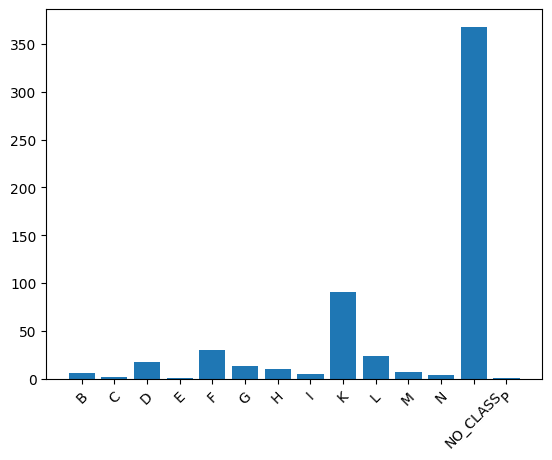

In [23]:
plt.bar(df_report.groupby("BERT_classification").count().index, df_report.groupby("BERT_classification").count()["Sentences"])
plt.xticks(rotation = 45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'A'),
  Text(1, 0, 'B'),
  Text(2, 0, 'C'),
  Text(3, 0, 'D'),
  Text(4, 0, 'E'),
  Text(5, 0, 'F'),
  Text(6, 0, 'G'),
  Text(7, 0, 'H'),
  Text(8, 0, 'I'),
  Text(9, 0, 'J'),
  Text(10, 0, 'K'),
  Text(11, 0, 'L'),
  Text(12, 0, 'M'),
  Text(13, 0, 'N'),
  Text(14, 0, 'O'),
  Text(15, 0, 'P'),
  Text(16, 0, 'Q'),
  Text(17, 0, 'S'),
  Text(18, 0, 'T'),
  Text(19, 0, 'U')])

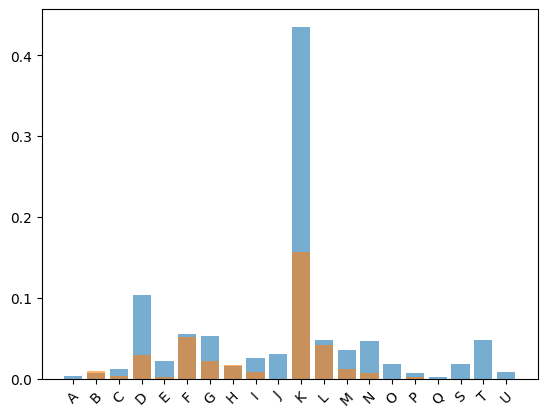

In [27]:
plt.bar(df_report.groupby("max_class_sim").count().index, df_report.groupby("max_class_sim").count()["Sentences"]/len(df_report), alpha = 0.6)
plt.bar(bert_classification.index, bert_classification["Sentences"]/len(df_report), alpha = 0.6)
plt.xticks(rotation = 45)

In [ ]:
df_report["max_class_sim"]

0      M
1      K
2      F
3      T
4      L
      ..
574    F
575    I
576    K
577    L
578    K
Name: max_class_sim, Length: 579, dtype: object

## Loop

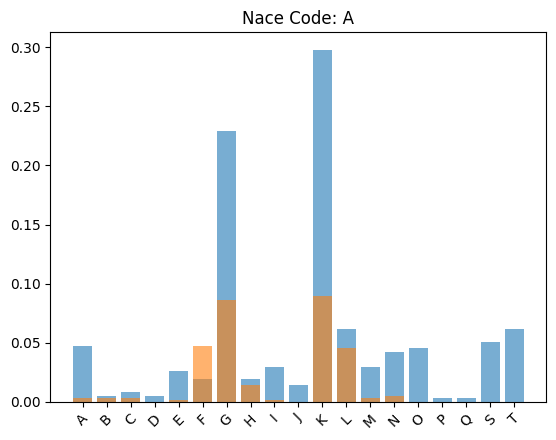

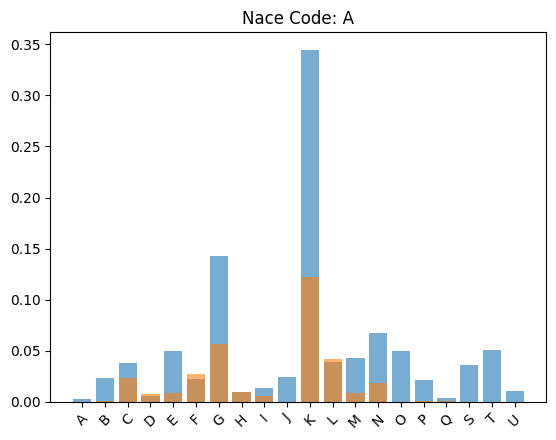

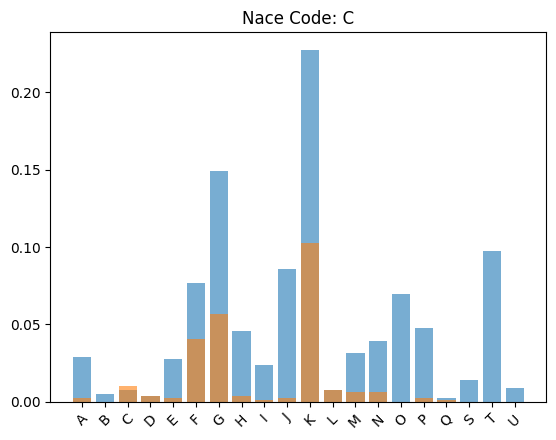

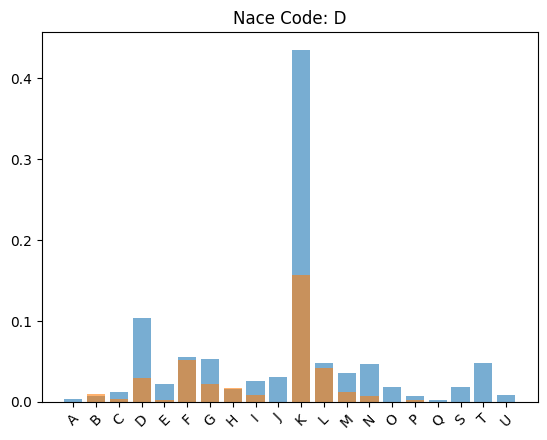

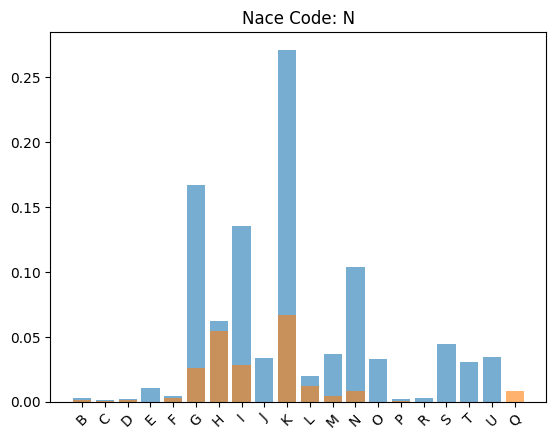

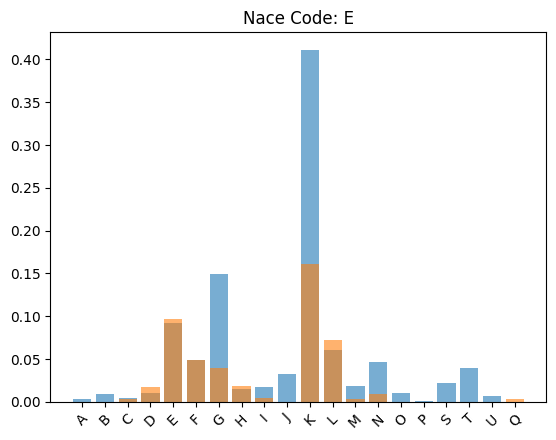

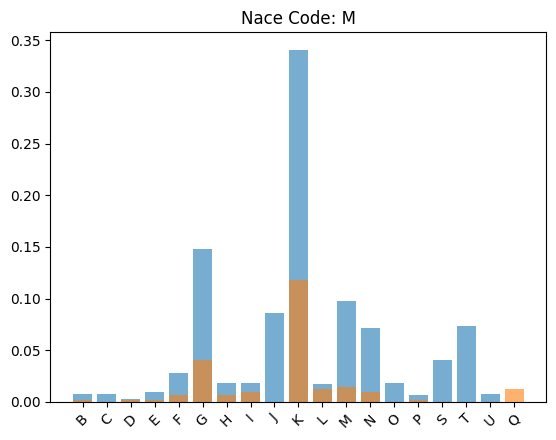

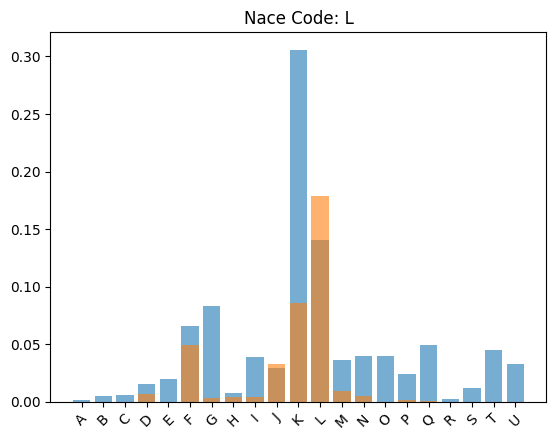

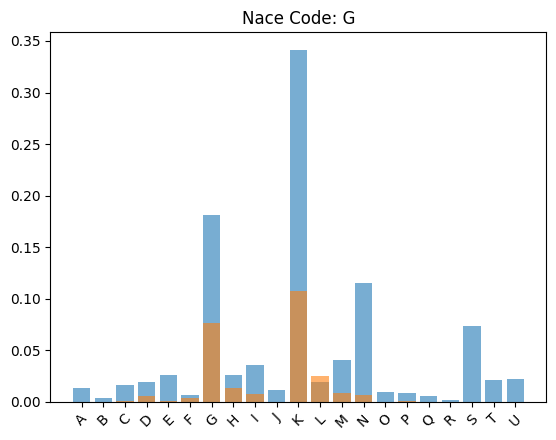

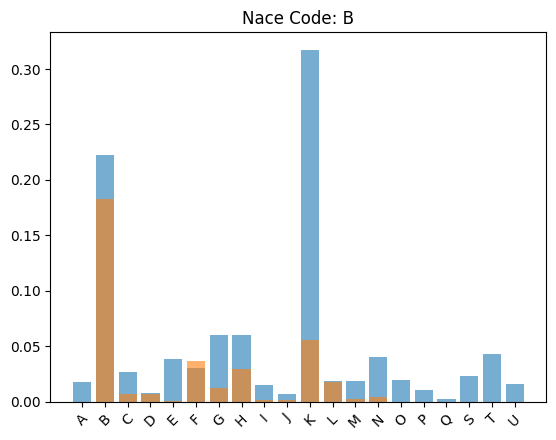

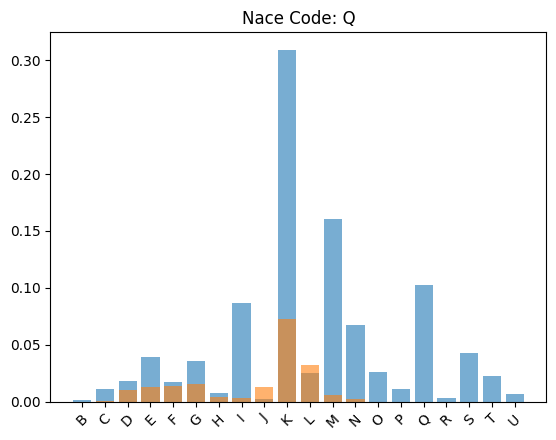

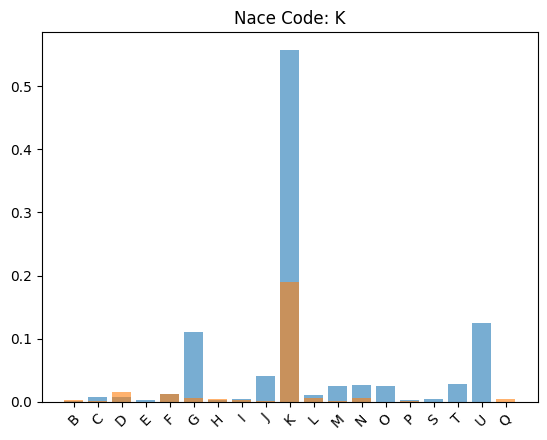

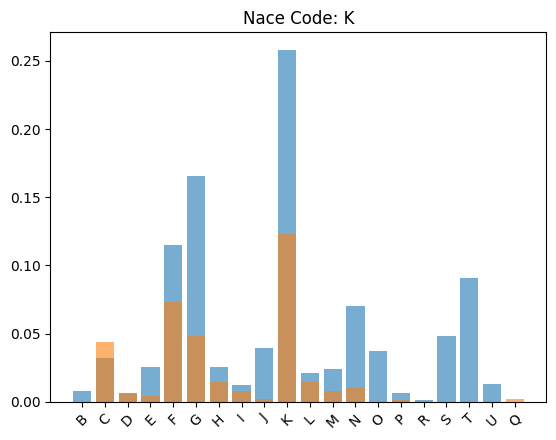

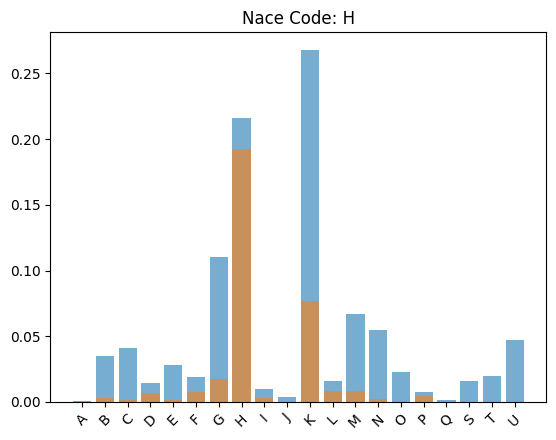

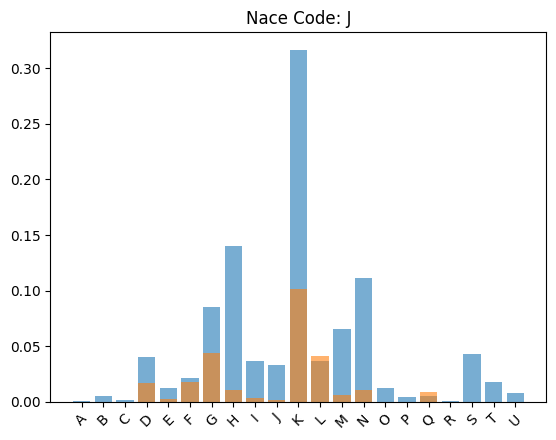

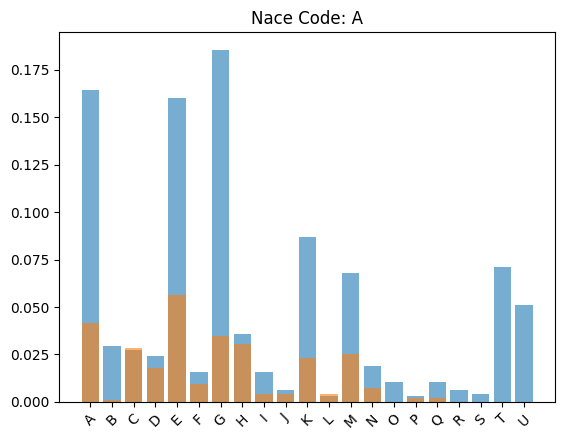

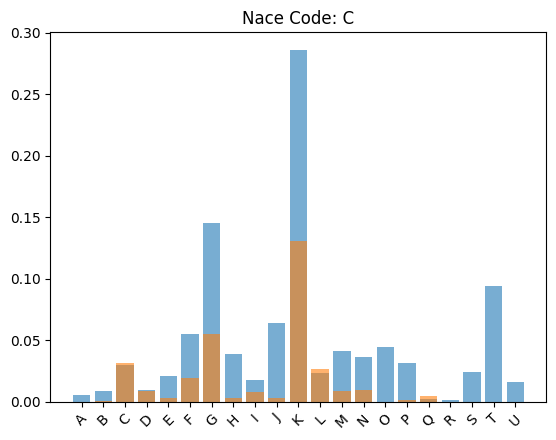

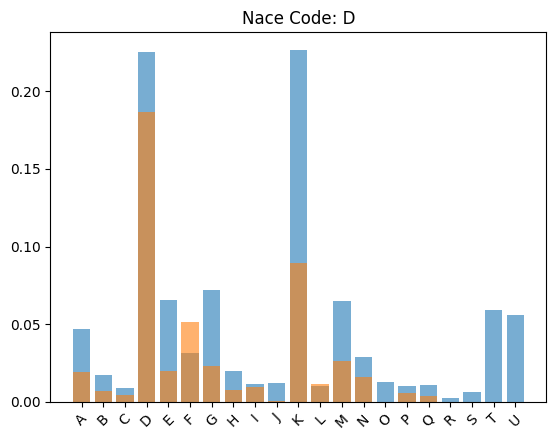

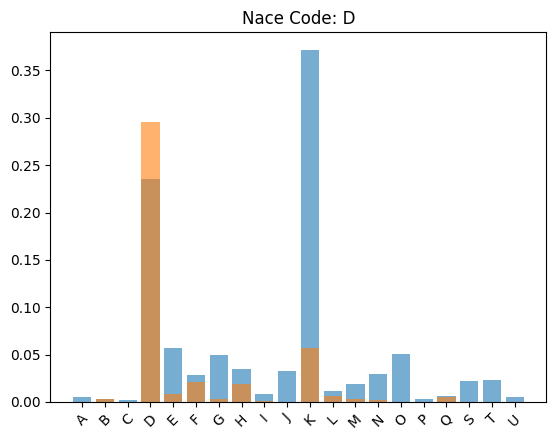

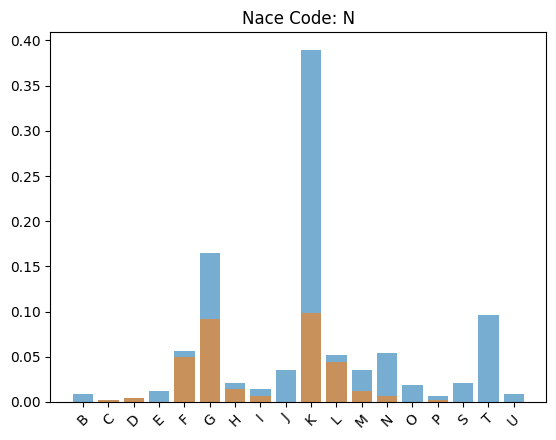

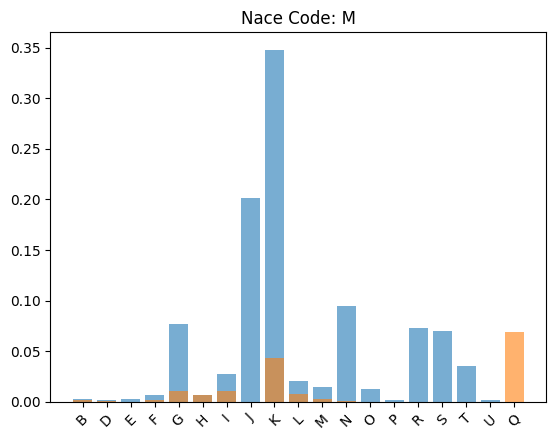

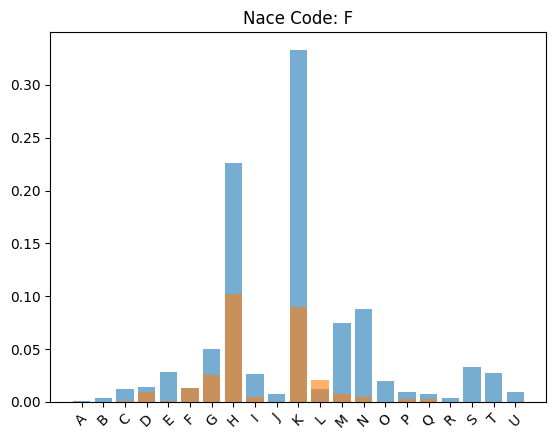

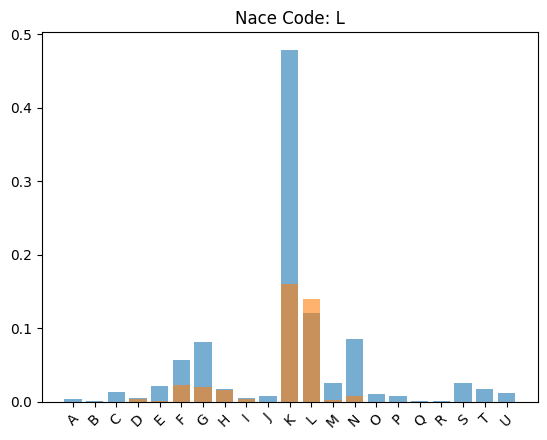

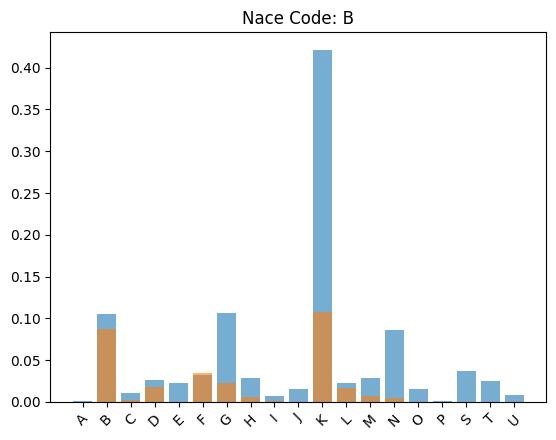

: 

: 

: 

In [ ]:
for report in report_paths:

    df_report = pd.read_csv(report, index_col=0)
    scores = [c for c in df_report.columns if "Scores" in c]
    df_report["max_class_sim"] = [scores[i][7] for i in np.argmax(df_report[scores], 1)]
    df_report["max_sim"] = df_report[scores].max(1)
    report_name = os.path.basename(report).split(".txt")[0] + ".pdf"

    report_code = nace_classes[nace_classes["Report"] == report_name]["NACE_letter"].item()

    df_report["right_class_sim"] = df_report["max_class_sim"] == report_code
    df_report["BERT_classification"] = df_report.loc[:,"Sentences"].apply(lambda x: get_max_class(x, model, tokenizer))

    np.mean(df_report[df_report["right_class_sim"]]["BERT_classification"] == df_report[df_report["right_class_sim"]]["max_class_sim"])

    df_report[(df_report["right_class_sim"]) & (df_report["max_sim"]>0.3)]

    np.mean(df_report[(df_report["right_class_sim"]) & (df_report["max_sim"]>0.3)]["BERT_classification"] == df_report[(df_report["right_class_sim"]) & (df_report["max_sim"]>0.3)]["max_class_sim"])
    df_report[df_report["right_class_sim"]]["max_class_sim"]
    df_report[df_report["right_class_sim"]]["BERT_classification"]
    df_report[df_report["right_class_sim"]]
    df_report.groupby("BERT_classification").count()
    bert_classification = df_report.groupby("BERT_classification").count()
    bert_classification = bert_classification[bert_classification.index != "NO_CLASS"]
    
    #plt.bar(df_report.groupby("BERT_classification").count().index, df_report.groupby("BERT_classification").count()["Sentences"])
    #plt.xticks(rotation = 45)
    plt.bar(df_report.groupby("max_class_sim").count().index, df_report.groupby("max_class_sim").count()["Sentences"]/len(df_report), alpha = 0.6, label="Similarities")
    plt.bar(bert_classification.index, bert_classification["Sentences"]/len(df_report), alpha = 0.6, label="BERT")
    plt.xticks(rotation = 45)
    plt.title(f"Nace Code: {report_code}")
    df_report["max_class_sim"]
    plt.show()

# Test on test data and observe

In [19]:
def softmax(x):
    e = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e / e.sum()

In [29]:
data_path = "data/training_data/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.35"
test_df = pd.read_csv(data_path + "/test_data.csv")
test_df

,text,Score,NACE_Code
0,based on the audit procedures performed we are...,0.402070,K
1,the res and others segment includes retail ele...,0.455005,D
2,the amount of contracts for overseas projects ...,0.393545,F
3,uraian satuan unit description penggunaan ener...,0.456308,A
4,interests payable on interestbearing mediumlon...,0.527204,NO_CLASS
...,...,...,...
28600,at december outstanding liabilities of million...,0.385393,K
28601,our underwriting focus is supported by excepti...,0.414353,K
28602,as the groups operations mainly focus on provi...,0.437924,F
28603,for sars and other cashsettled share option sc...,0.431704,K


In [41]:
for i in range(5):
    res = pd.DataFrame.from_dict(BERT_classification_chunk(test_df.loc[i, "text"], model, tokenizer), orient="index")
    print(test_df.loc[i, "text"])
    print(res.sort_values(0, ascending=False))
    res = softmax(res).sort_values(0, ascending=False)
    print(res)
    print(test_df.loc[i, "NACE_Code"])
    print()
    print()
    print()
    print("______")


based on the audit procedures performed we are satisfied with existence and valuation of investments. b consolidation procedure the company has four associates. one associate also holds shares of company resulting in a cross holding. at each reporting date company consolidates such associate after eliminating crossholding effect. we have obtained an understanding of procedure used by management for consolidation amp elimination of effect of cross holding at reporting date. based on the audit procedures performed we are satisfied with the procedure followed by the management for consolidation of associates after elimination of effect of cross holding.
                 0
NO_CLASS  8.951086
F         1.230388
K         0.975865
I         0.611288
N         0.573050
C        -0.275053
H        -0.283502
Q        -0.358623
G        -0.767424
M        -0.826146
P        -1.309827
E        -1.456283
B        -3.068388
A        -3.104759
J        -3.475658
D        -3.526119
L        -4.228030